<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Python Data Visualization
---


### Introduction

We will introduce how plotting works in Pandas and Matplotlib. It is important to know that Pandas uses Matplotlib behind the scenes to make plots. So, you will notice that Pandas plotting methods often use similar parameter names as Matplotlib methods. Further, you can use Matplotlib functions in combination with Pandas methods to alter the plots after drawing them. For example, you can use Matplotlib's `xlabel` and `title` functions to label the plot's x-axis and title, respectively, after it is drawn.

As we explore different types of plots, notice:

1. Different types of plots are drawn very similarly -- they even tend to share parameter names.
2. In Pandas, calling `plot()` on a `DataFrame` is different than calling it on a `Series`. Although the methods are both named `plot`, they may take different parameters.

Toward the end , we will show some motivational plots using Seaborn, a popular statistics plotting library, as well as go more in-depth about how Matplotlib works.

### Quick Recap: Choosing the right type of visualization

The choice of visualization should depend what you are trying to show. Here is a helpful flowchart that you can use to determine the best type of visualizations.

__👉[Data-To-Viz: Data visualization guide](https://www.data-to-viz.com/#explore)__


<img src="https://www.climber.se/wp-content/uploads/2020/02/climber_qlik_visualisation_1400.jpg" width="80%">


__⚠️ Before you get started with visualizing our data!__ Always inspect your data and check if it needs to be cleaned

In [6]:
# import pandas library
import pandas as pd

In [7]:
# open csv 'international_football_results.csv' using pd.read_csv
# the the dataframe as football

football = pd.read_csv("./data/international_football_results.csv")
football.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


## EDA:

__Find the number of records and features__

In [8]:
# Find the number of records (rows) and features (columns)
football.shape

(39669, 9)

__Let's inspect the data types and missing values in our data__

In [9]:
# Missing values
football.isnull().sum()


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [10]:
# You can get the number of features and records, missing values and data types using .info()
football.info()


<class 'pandas.DataFrame'>
RangeIndex: 39669 entries, 0 to 39668
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        39669 non-null  str  
 1   home_team   39669 non-null  str  
 2   away_team   39669 non-null  str  
 3   home_score  39669 non-null  int64
 4   away_score  39669 non-null  int64
 5   tournament  39669 non-null  str  
 6   city        39669 non-null  str  
 7   country     39669 non-null  str  
 8   neutral     39669 non-null  bool 
dtypes: bool(1), int64(2), str(6)
memory usage: 2.5 MB


__Are there any columns we need to adjust?__

In [11]:
# Convert the 'date' column to datetime using pd.to_datetime()

football["date"] = pd.to_datetime(football["date"])


In [13]:
# Check if the data type changed using dtypes
football.dtypes


date          datetime64[us]
home_team                str
away_team                str
home_score             int64
away_score             int64
tournament               str
city                     str
country                  str
neutral                 bool
dtype: object

## Let's dig into our data and get some insights

### How many games were hosted by year?
- We need to create a column that contains the year only

In [14]:
# What features do we need? and How can we get that information?
# Extract year from 'date'. 
# use google to search on how to do it
football["year"]= football["date"].dt.year


# show the head of football dataframe
football.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876


In [24]:
# Now that we have the year extracted, how can we count the number of games_per_year?

# Why do we need to sort the index of years?

# try to plot without sorting the index
games_per_year = football["year"].value_counts().sort_index()
games_per_year

year
1872       1
1873       1
1874       1
1875       1
1876       2
        ... 
2014     857
2015    1001
2016     918
2017     908
2018     390
Name: count, Length: 147, dtype: int64

__We can visualize the above to get a better idea of how the number of football games changed over time.__

__Pandas__ has a plotting method that allows you to visualize your data, using the Matplotlib library to convert DataFrames and Series into visualizations.

**_ℹ️ Keep in mind, you are not expected to memorize the code!!!_** 

👉 __[Visit the Documentation](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.plot.html)__

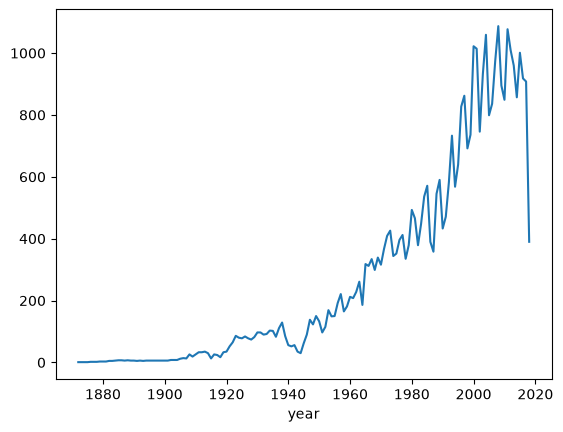

In [29]:
# Let's look how the number of games changed over time 🤔
# .plot() will display a line chart by default
# We add a ; (semicolon) at the end of .plot() to remove the weird text above the chart
games_per_year.plot();


In [30]:
# Notice the dip in at the end of the chart. What do you think is the cause of it? and How to fix it?
# check what is the maximum date in the dataframe using .max()

football["date"].max()

Timestamp('2018-07-10 00:00:00')

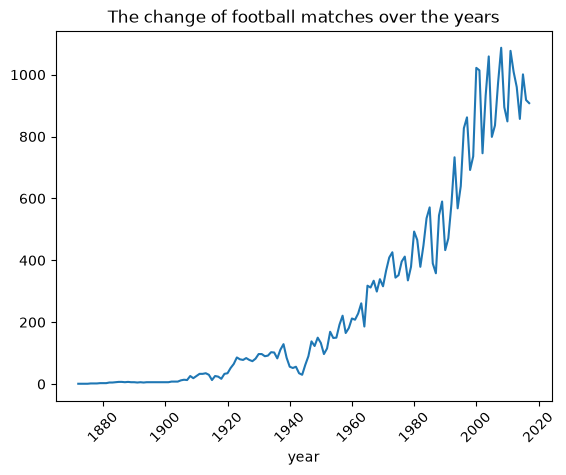

In [33]:
# Exclude the last year by slicing the Series using [:-1]
# Add a title to the chart
# Rotate the x-axis labels to 45 degrees
games_per_year[:-1].plot(title ="The change of football matches over the years",rot=45);



__We can change the above to a bar chart__

<Axes: title={'center': 'The changes in football matches over the last 10 years'}, xlabel='year'>

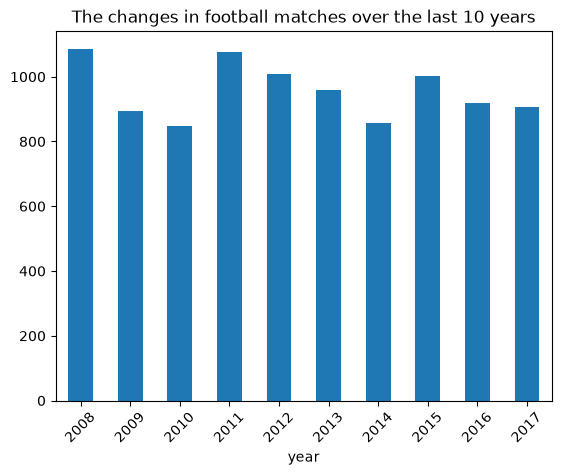

In [46]:
# This is a lot, and unclear. Let us look at the last 10 years. What do we notice?
# games_per_year[-11:-1].plot(title = "The changes in football matches over the last 10 years",rot=45)
games_per_year[-11:-1].plot(kind="bar", title="The changes in football matches over the last 10 years",rot=45)



### Pie Chart

- __What percentage of games were played on Neutral grounds?__

In [47]:
# Find the number of Neutral games and Non-Nutral. Guess how to find it?
neutral_games = football["neutral"].value_counts()
neutral_games


neutral
False    29848
True      9821
Name: count, dtype: int64

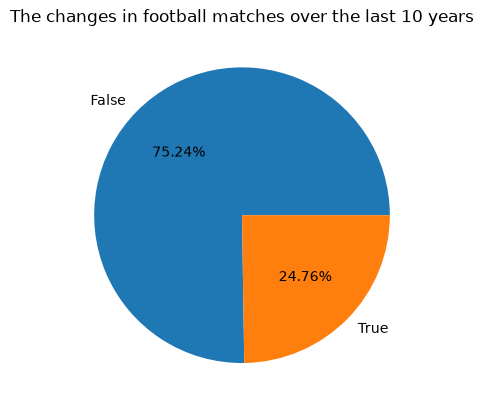

In [52]:
# Let's try and plot a Pie chart using pandas. This time we will display the percentage of each segment
neutral_games.plot(kind="pie",
                    title="The changes in football matches over the last 10 years",
                   autopct="%1.2f%%",rot=45);




However, pandas built in visualizations has certain limits to it. There are other visualization that we can work with like matplotlib which has some of its features integrated in pandas and the other is seaborn.

## Matplotlib 

A fundamental plotting library for the Python programming language. It's widely used for creating a variety of static, animated, and interactive visualizations. Think of it as a powerful toolkit that allows you to transform raw data into insightful charts, graphs, and figures.

- __[Documentation](https://matplotlib.org/stable/users/index)__
- __[Cheatsheets & Handouts](https://matplotlib.org/cheatsheets/)__ 
  
__To modify the chart layout throughout the notebook. (View matplotlib [chart themes](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html))__
- To change the chart theme.
```python
plt.style.use()
```
- Change default figure and font sizes.
```python
plt.rcParams
```

In [53]:
import matplotlib.pyplot as plt

# Change the theme to 'fast'
plt.style.use('fast')
%matplotlib inline

# Increase default figure and font sizes for easier viewing.
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10

### Let's try to plot the previous pie chart using matplotlib

Text(0.5, 1.0, 'neutral and Non-Neutral')

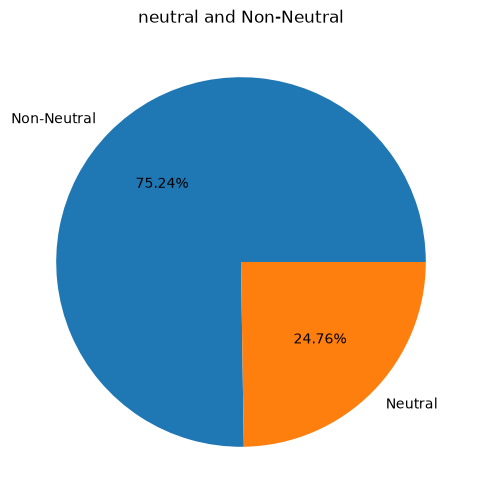

In [57]:
# let's show what is neutral_games
plt.pie(neutral_games.values,labels=["Non-Neutral","Neutral"], autopct="%1.2f%%")
plt.title("neutral and Non-Neutral")

In [34]:
# Let's try and plot a Pie chart using matplotlib. This time we will display the percentage of each segment
# plt.pie(neutral_games.values, labels=['Non-Neutral','Neutral'], autopct='%1.2f%%')

# Add titles and labels
# plt.title('25% of games played are on Neutral grounds')

# show the plot
# plt.show()

- __How many games were played in each of those tournaments?__

In [76]:
# Top 10 tournament by number of games

games_per_tournament = football["tournament"].value_counts().head(10)
games_per_tournament

tournament
Friendly                                16475
FIFA World Cup qualification             7100
UEFA Euro qualification                  2332
African Cup of Nations qualification     1558
FIFA World Cup                            897
Copa América                              787
AFC Asian Cup qualification               724
African Cup of Nations                    638
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Name: count, dtype: int64

### Bar plot using Pandas vs. Matplotlib

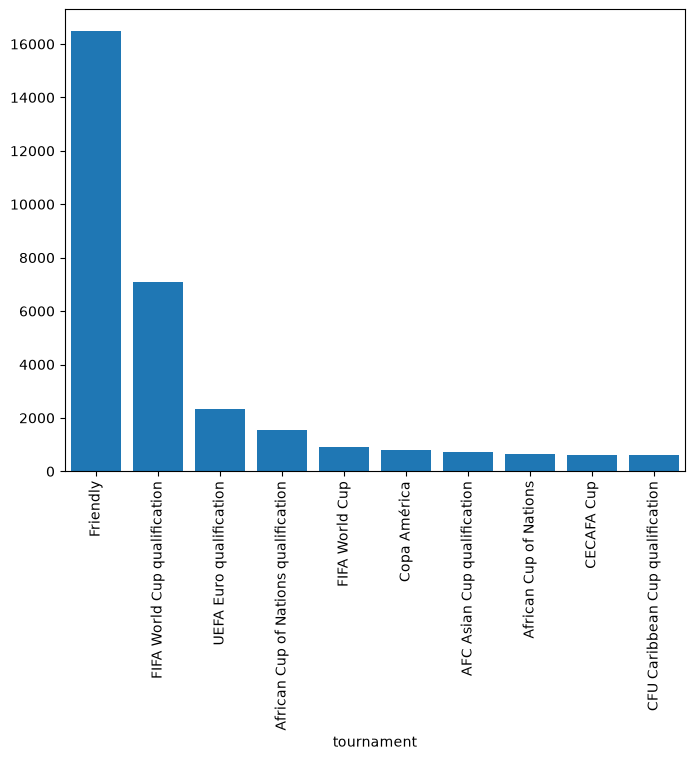

In [77]:
# bar plot using pandas
games_per_tournament.plot(kind="bar")

# bar plot using matplotlib
plt.bar(data=games_per_tournament,x= games_per_tournament.index,height=games_per_tournament.values)
plt.xticks(rotation = 90);


### Horizental Bar plot using Pandas vs. Matplotlib

<BarContainer object of 10 artists>

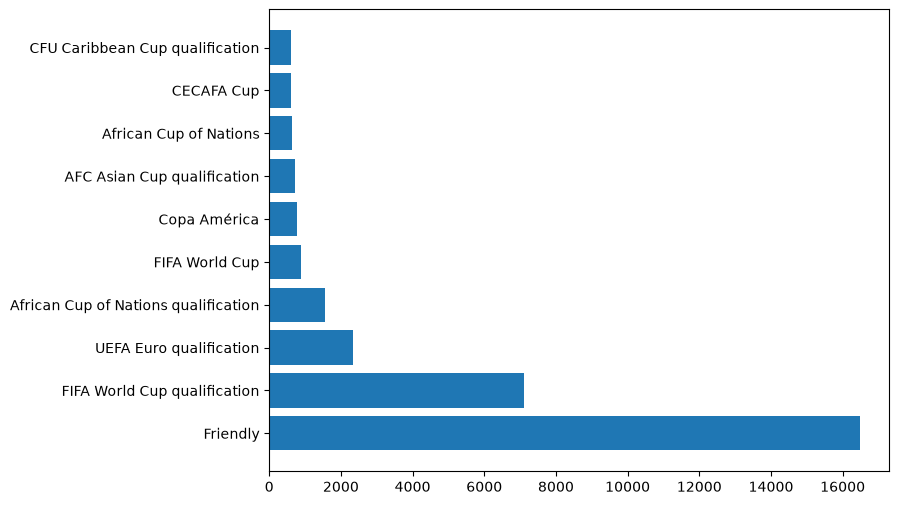

In [78]:
# Barh using pandas

# games_per_tournament= games_per_tournament.plot(kind="barh")

# bar plot using matplotlib

plt.barh(data = games_per_tournament, 
         y= games_per_tournament.index, 
         width = games_per_tournament.values)




### Add chart title, xlabel, ylabel

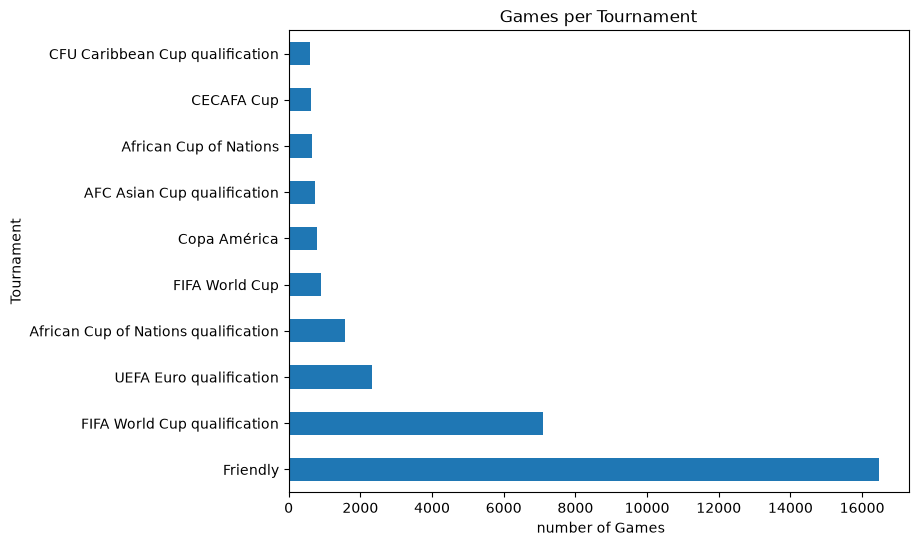

In [82]:
# Barh using pandas
games_per_tournament.plot(kind='barh')
plt.title('Games per Tournament')
plt.xlabel(' number of Games')
plt.ylabel('Tournament');



__Matplotlib allows you to customize your visualizations, taking them a step further in detail and presentation.__

__For more information on how to modify your chart, check out [Matplotlib Anatomy](https://matplotlib.org/stable/users/explain/quick_start.html)__
<div align="middle"><img src="https://matplotlib.org/stable/_images/anatomy.png" width="60%"></img></div>

## Using AI/ChatGPT to help in plot code

Formatting charts in Python can be really tedious and time-consuming compared to tools like Power BI and Tableau. This is one of the exceptions where you can utilize Generative AI: to generate the code to plot a chart. Keep in mind that the code it generates purely depends on the prompt you give it, and your understanding of pandas and visualization best practices.

__Rule of Thumb:__
- By default, the generated code will include importing libraries. When dealing with libraries, you only need to import a library once, and it should be right at the beginning of your notebook.

- The AI will often use sample data it generates for demonstration purposes. You'll need to know how to connect your own data to the plotting code it provides.

- __Always test the generated code!__ You cannot rely 100% on what it produces. If you encounter an error, you can always reply to the AI with the error message to get assistance.

- If you're interested in a deeper understanding of how the code works, ask the AI, and it will provide an explanation. Ideally, you should also check the official documentation.

#### Is there a relationship between Number of tournaments per year and total score per year?

In [83]:
# show the head of football
football.head(2)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873


In [84]:
# let's calculate total goals scores 

football["total_goals_scored"]= football["home_score"] + football["away_score"]

football.head(2)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals_scored
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6


In [85]:
# Find the number of tournaments and total goal scored for each year
tournaments_vs_scores = football.groupby("year").agg({"tournament":"count",
                                                      "total_goals_scored": "sum"
                                                     })


tournaments_vs_scores


,tournament,total_goals_scored
year,,
1872,1,0
1873,1,6
1874,1,3
1875,1,4
1876,2,7
...,...,...
2014,857,2244
2015,1001,2676
2016,918,2495


Let's use Generative AI (e.g.:**[ChatGPT](https://chatgpt.com/)**) to generate a scatter plot to show the relationship between the number of tournaments and total goals scored.

__This is an example prompt:__
```
Generate Python code to create a scatter plot. The plot should visualize the relationship between 'Number of Tournaments' (on the x-axis) and 'Total Goals Scored' (on the y-axis). Assume the data is in a pandas DataFrame named df with columns tournament and total_goals_scored.
Please include the following plot details:
- Plot Title: 'Number of Tournaments vs. Total Goals Scored'
- X-axis Label: 'Number of Tournaments'
- Y-axis Label: 'Total Goals Scored'
- The scatter points should be colored 'Dark Green'
```

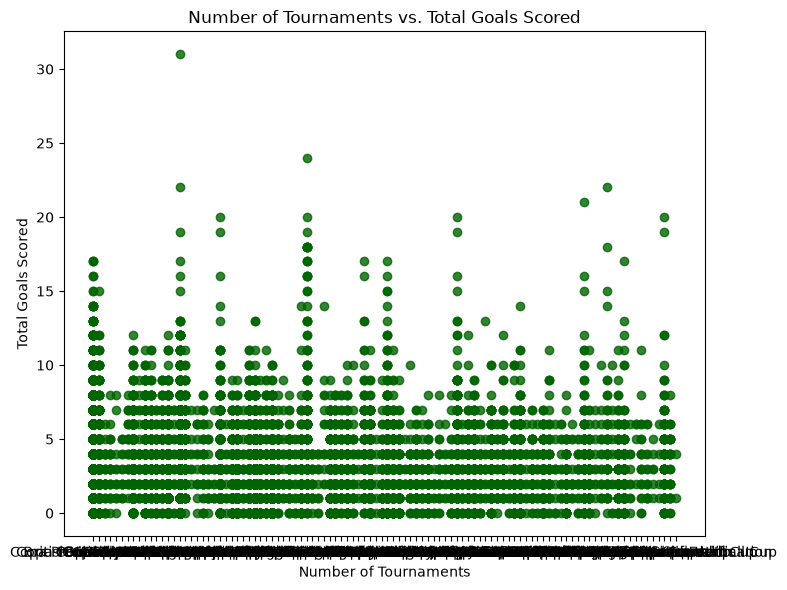

In [92]:
# try the ChatGPT respond to plot the scatter chart
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(
    football["tournament"],
    football["total_goals_scored"],
    color="darkgreen",
    alpha =0.8
)

# Add title and axis labels
plt.title("Number of Tournaments vs. Total Goals Scored")
plt.xlabel("Number of Tournaments")
plt.ylabel("Total Goals Scored")

# Display the plot
plt.tight_layout()
plt.show()


### Saving a figure

__Refer to the figure object and indicate the filename and desired format. View the [docummentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html)__

__Note:__ *This must be added before ```plt.show()``` , otherwise you will get a blank image*

```python
plt.savefig("png_format_chart.png")
plt.savefig('pdf_format_chart.pdf', format='pdf')
```

In [41]:
# try the ChatGPT respond to plot the scatter chart
# save the figure as png format

plt.savefig("png_format_chart.png")
plt.savefig('pdf_format_chart.pdf', format='pdf')

#### Provide ChatGPT with the below chart and ask to create a python code to it

<div>
<img src="attachment:941d47b4-4357-44bc-a738-58e55944a93e.png" width="300">
</div>



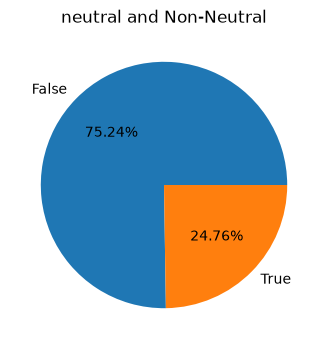

In [97]:
# What is the code provided by ChatGPT:
# you have to change the data taken from and some parameters
# Plotting the pie chart
import matplotlib.pyplot as plt

# Count each category
counts = football["neutral"].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 4))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.2f%%",
)

plt.title("neutral and Non-Neutral")
plt.show()




### Saving the cleaned data
⚠️ __Rule of thumb:__ DO NOT overwrite the original data !

In [43]:
# The "index = False" will not save the index in the new csv file 



### Additional resources

Take a look at the matplotlib and seaborn documentation for some inspiration. D3 also have good resources on its website.

Click here for more:

- [Matplotlib gallery](http://matplotlib.org/gallery/index.html)

- [Seaborn gallery](http://seaborn.pydata.org/examples/index.html)

- [D3 gallery](https://github.com/mbostock/d3/wiki/Gallery)

- [Python Graph Gallery](https://python-graph-gallery.com/)